# Snowball Saturation and Seed-Sensitivity Simulation

In [19]:
"""
Snowball saturation & seed-sensitivity simulation
==================================================
Robustness / sensitivity analysis for the 12-chain, 18-seed snowball review
(Afdideh, Seoane & Abtahi, six-dimensional adaptation taxonomy).

This models the OPPORTUNITY STRUCTURE of the seed set, not the actual
citation log. Seed->item reachability is sampled from category-level
affinity parameters (documented assumptions), with every retained item
forced reachable from >=1 seed (since all retained items were in fact
discovered). Discovery timing per active link ~ Geometric(q(affinity)).

Fixed RNG seed, 5000 Monte Carlo replicates.
"""

import numpy as np
import matplotlib.pyplot as plt
import csv

import os
import warnings
warnings.filterwarnings('ignore')

RNG_SEED = 2026
N_REP = 5000
MAX_ITER = 10          # snowball rounds simulated
rng = np.random.default_rng(RNG_SEED)

# ----------------------------------------------------------------------
# 1. PARAMETERIZATION (Tables S1-S12)
# ----------------------------------------------------------------------
CHAINS = ["PEFT", "TL", "Merging", "RLVR", "Align", "CL",
          "Meta", "RAG", "Edit", "Unlearn", "Steer", "Aug", "Grey"]
C = {c: i for i, c in enumerate(CHAINS)}

# Retained items per category: ~130 academic + ~20 grey = 150
ITEM_COUNTS = {"PEFT": 17, "TL": 12, "Merging": 11, "RLVR": 12,
               "Align": 11, "CL": 5, "Meta": 10, "RAG": 10,
               "Edit": 10, "Unlearn": 10, "Steer": 9, "Aug": 6,
               "Grey": 20}
assert sum(ITEM_COUNTS.values()) == 143

# 18 seeds (Tables S1-S12), home chain, practitioner flag
# (practitioner flag = LLM-era seed plausibly adjacent to grey literature)
SEEDS = [
    ("Hu2022_LoRA",        "PEFT",    True),
    ("PanYang2010",        "TL",      False),
    ("Zhuang2021",         "TL",      False),
    ("Ilharco2023",        "Merging", True),
    ("Rafailov2023_DPO",   "Align",   True),
    ("Ouyang2022_RLHF",    "Align",   True),
    ("DeepSeekR1_2025",    "RLVR",    True),
    ("Shao2024_GRPO",      "RLVR",    True),
    ("Shi2024_CLsurvey",   "CL",      False),
    ("Finn2017_MAML",      "Meta",    False),
    ("Hospedales2021",     "Meta",    False),
    ("Lewis2020_RAG",      "RAG",     True),
    ("Meng2022_ROME",      "Edit",    True),
    ("CaoYang2015",        "Unlearn", False),
    ("Zou2023_RepE",       "Steer",   True),
    ("Turner2023_ActAdd",  "Steer",   True),
    ("Wang2024_AugSurvey", "Aug",     True),
    ("Zhou2024_AugSurvey", "Aug",     True),
]
S = len(SEEDS)

# Category-level affinity assumptions
AFF_OWN, AFF_WEAK = 0.90, 0.03
RELATED = {  # symmetric cross-chain affinities (documented assumptions)
    ("PEFT", "TL"): 0.30, ("PEFT", "Merging"): 0.30,
    ("TL", "CL"): 0.30, ("TL", "Meta"): 0.30, ("CL", "Meta"): 0.30,
    ("RLVR", "Align"): 0.45,               # GRPO/DAPO bridge (strong)
    ("Merging", "Unlearn"): 0.30,          # task-vector negation
    ("Edit", "Unlearn"): 0.30,
    ("Steer", "Edit"): 0.20,
    ("Aug", "Align"): 0.20,                # Self-Instruct-style data
    ("RAG", "Grey"): 0.35,                 # RAG <-> context-engineering grey lit
}
GREY_AFF_PRACT, GREY_AFF_OTHER = 0.18, 0.03

def affinity(seed_idx, cat):
    name, home, pract = SEEDS[seed_idx]
    if cat == home:
        return AFF_OWN
    if cat == "Grey":
        base = GREY_AFF_PRACT if pract else GREY_AFF_OTHER
        extra = RELATED.get((home, "Grey"), RELATED.get(("Grey", home), 0.0))
        return max(base, extra)
    r = RELATED.get((home, cat), RELATED.get((cat, home), 0.0))
    return max(r, AFF_WEAK)

def q_of(p):
    """Geometric firing prob per iteration as function of affinity."""
    return np.clip(0.15 + 0.60 * p, 0.15, 0.70)

# Item arrays
item_cat = np.concatenate([[C[c]] * n for c, n in ITEM_COUNTS.items()])
N = len(item_cat)
# Seed x category affinity, expanded to seed x item
A_cat = np.array([[affinity(s, c) for c in CHAINS] for s in range(S)])
P = A_cat[:, item_cat]              # (S, N) link probabilities
Q = q_of(P)                          # (S, N) geometric firing probs
home_seed_of_cat = {c: [i for i, sd in enumerate(SEEDS) if sd[1] == c]
                    for c in CHAINS}
pract_seeds = [i for i, sd in enumerate(SEEDS) if sd[2]]

# ----------------------------------------------------------------------
# 2. MONTE CARLO
# ----------------------------------------------------------------------
cum_frac = np.zeros((N_REP, MAX_ITER + 1))          # A
loso_all = np.zeros((N_REP, S))                     # B (overall)
loso_own = np.zeros((N_REP, S))                     # B (own-chain items)
N_PERM = 8
cov_k = np.zeros((N_REP, N_PERM, S))                # C
redund = np.zeros((N_REP, N))                       # D

own_items = []
for s in range(S):
    own_items.append(np.where(item_cat == C[SEEDS[s][1]])[0])

for r in range(N_REP):
    R = rng.random((S, N)) < P                       # reachability draw
    # force every retained item reachable (it was, in fact, retained)
    unreached = np.where(~R.any(axis=0))[0]
    for i in unreached:
        cat = CHAINS[item_cat[i]]
        pool = home_seed_of_cat[cat] if cat != "Grey" else pract_seeds
        R[rng.choice(pool), i] = True
    # discovery times: geometric per active link
    T = np.full((S, N), np.inf)
    active = np.where(R)
    T[active] = rng.geometric(Q[active])
    t_item = T.min(axis=0)
    for t in range(MAX_ITER + 1):
        cum_frac[r, t] = np.mean(t_item <= t)
    # LOSO (asymptotic reachability without each seed)
    reach_ct = R.sum(axis=0)
    redund[r] = reach_ct
    for s in range(S):
        others = reach_ct - R[s]
        loso_all[r, s] = np.mean(others > 0)
        loso_own[r, s] = np.mean(others[own_items[s]] > 0)
    # coverage vs number of seeds
    for p_i in range(N_PERM):
        perm = rng.permutation(S)
        acc = np.logical_or.accumulate(R[perm], axis=0)
        cov_k[r, p_i] = acc.mean(axis=1)

# ----------------------------------------------------------------------
# 3. AGGREGATE
# ----------------------------------------------------------------------
sat_mean = cum_frac.mean(0)
sat_lo, sat_hi = np.percentile(cum_frac, [2.5, 97.5], axis=0)
it95 = int(np.argmax(sat_mean >= 0.95))
it99 = int(np.argmax(sat_mean >= 0.99))

loso_all_m, loso_all_sd = loso_all.mean(0), loso_all.std(0)
loso_own_m = loso_own.mean(0)

covk = cov_k.reshape(-1, S)
covk_m = covk.mean(0)
covk_lo, covk_hi = np.percentile(covk, [2.5, 97.5], axis=0)

red_item_m = redund.mean(0)
red_cat_m = np.array([red_item_m[item_cat == C[c]].mean() for c in CHAINS])
red_cat_sd = np.array([red_item_m[item_cat == C[c]].std() for c in CHAINS])
frac_single = np.mean(red_item_m < 1.5)

# Visualizations

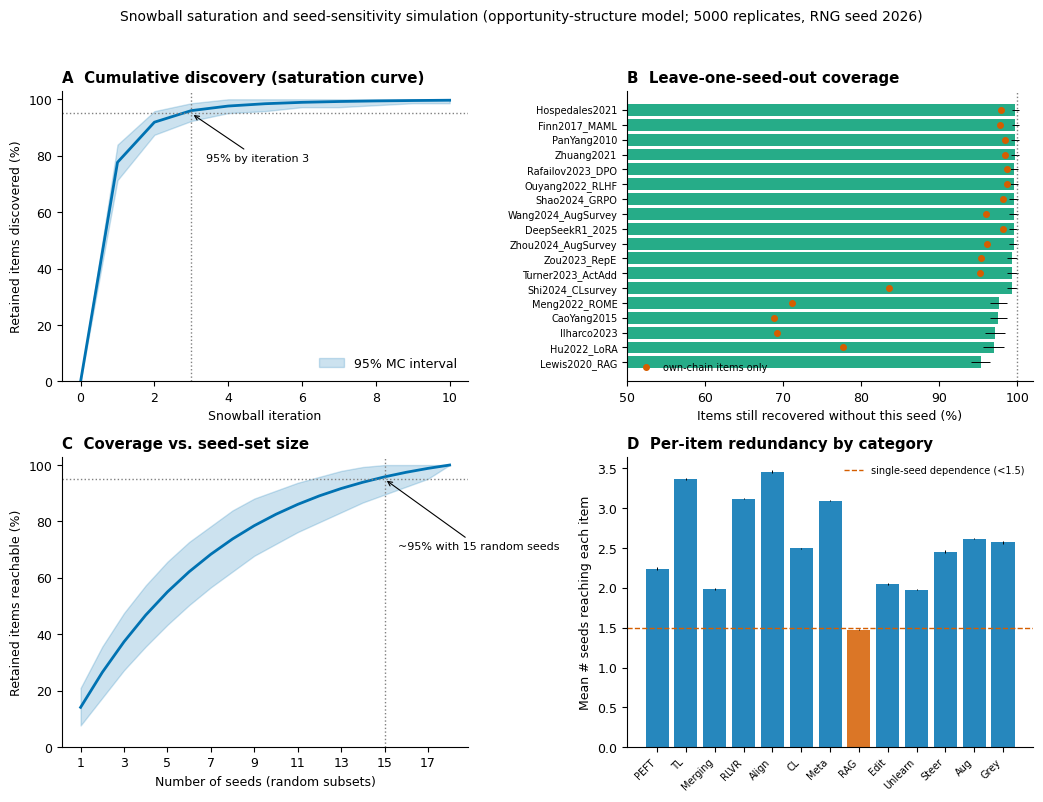

Saved: fig/seed_sensitivity.png


In [20]:
# ----------------------------------------------------------------------
# 4. FIGURE
# ----------------------------------------------------------------------

os.makedirs('fig', exist_ok=True)

plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.0))
(axA, axB), (axC, axD) = axes

# A: saturation curve
axA.plot(range(MAX_ITER + 1), sat_mean * 100, color="#0072B2", lw=2)
axA.fill_between(range(MAX_ITER + 1), sat_lo * 100, sat_hi * 100,
                 color="#0072B2", alpha=0.20, label="95% MC interval")
axA.axhline(95, color="grey", ls=":", lw=1)
axA.axvline(it95, color="grey", ls=":", lw=1)
axA.annotate(f"95% by iteration {it95}", xy=(it95, 95),
             xytext=(it95 + 0.4, 78), fontsize=8,
             arrowprops=dict(arrowstyle="->", lw=0.8))
axA.set_xlabel("Snowball iteration"); axA.set_ylabel("Retained items discovered (%)")
axA.set_title("A  Cumulative discovery (saturation curve)", loc="left", fontweight="bold")
axA.set_ylim(0, 103); axA.legend(frameon=False, loc="lower right")

# B: leave-one-seed-out
order = np.argsort(loso_all_m)
names = [SEEDS[i][0] for i in order]
axB.barh(range(S), loso_all_m[order] * 100, xerr=loso_all_sd[order] * 100,
         color="#009E73", alpha=0.85, error_kw=dict(lw=0.7))
axB.plot(loso_own_m[order] * 100, range(S), "o", color="#D55E00", ms=4,
         label="own-chain items only")
axB.set_yticks(range(S)); axB.set_yticklabels(names, fontsize=7)
axB.axvline(100, color="grey", ls=":", lw=1)
axB.set_xlabel("Items still recovered without this seed (%)")
axB.set_title("B  Leave-one-seed-out coverage", loc="left", fontweight="bold")
axB.set_xlim(50, 102); axB.legend(frameon=False, loc="lower left", fontsize=7)

# C: coverage vs number of seeds
axC.plot(range(1, S + 1), covk_m * 100, color="#0072B2", lw=2)
axC.fill_between(range(1, S + 1), covk_lo * 100, covk_hi * 100,
                 color="#0072B2", alpha=0.20)
axC.axhline(95, color="grey", ls=":", lw=1)
k95 = int(np.argmax(covk_m >= 0.95)) + 1
axC.axvline(k95, color="grey", ls=":", lw=1)
axC.annotate(f"~95% with {k95} random seeds", xy=(k95, 95),
             xytext=(k95 + 0.6, 70), fontsize=8,
             arrowprops=dict(arrowstyle="->", lw=0.8))
axC.set_xlabel("Number of seeds (random subsets)")
axC.set_ylabel("Retained items reachable (%)")
axC.set_title("C  Coverage vs. seed-set size", loc="left", fontweight="bold")
axC.set_xticks(range(1, S + 1, 2)); axC.set_ylim(0, 103)

# D: redundancy per category
xd = np.arange(len(CHAINS))
colors = ["#D55E00" if m < 1.5 else "#0072B2" for m in red_cat_m]
axD.bar(xd, red_cat_m, yerr=red_cat_sd, color=colors, alpha=0.85,
        error_kw=dict(lw=0.7))
axD.axhline(1.5, color="#D55E00", ls="--", lw=1,
            label="single-seed dependence (<1.5)")
axD.set_xticks(xd); axD.set_xticklabels(CHAINS, rotation=45, ha="right", fontsize=7)
axD.set_ylabel("Mean # seeds reaching each item")
axD.set_title("D  Per-item redundancy by category", loc="left", fontweight="bold")
axD.legend(frameon=False, fontsize=7)

fig.suptitle("Snowball saturation and seed-sensitivity simulation "
             f"(opportunity-structure model; {N_REP} replicates, RNG seed {RNG_SEED})",
             fontsize=10, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("fig/seed_sensitivity.png", dpi=300)
plt.show()
print("Saved: fig/seed_sensitivity.png")

# Summary

In [21]:
# ----------------------------------------------------------------------
# 5. CSV OUTPUTS
# ----------------------------------------------------------------------
with open("fig/snowball_sim_results.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["block", "name", "home_chain", "metric", "value"])
    for s in range(S):
        w.writerow(["LOSO", SEEDS[s][0], SEEDS[s][1],
                    "overall_coverage_pct", f"{loso_all_m[s]*100:.2f}"])
        w.writerow(["LOSO", SEEDS[s][0], SEEDS[s][1],
                    "own_chain_coverage_pct", f"{loso_own_m[s]*100:.2f}"])
    for i, c in enumerate(CHAINS):
        w.writerow(["REDUNDANCY", c, c, "mean_seeds_per_item",
                    f"{red_cat_m[i]:.2f}"])
    w.writerow(["SATURATION", "all", "-", "iter_to_95pct", it95])
    w.writerow(["SATURATION", "all", "-", "iter_to_99pct", it99])
    w.writerow(["SUBSET", "all", "-", "k_for_95pct_coverage", k95])
    w.writerow(["SUBSET", "all", "-",
                "marginal_gain_12_to_18_seeds_pct",
                f"{(covk_m[17]-covk_m[11])*100:.2f}"])
    w.writerow(["REDUNDANCY", "all", "-",
                "frac_items_redundancy_below_1.5_pct",
                f"{frac_single*100:.2f}"])

with open("fig/snowball_sim_curves.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["curve", "x", "mean_pct", "lo95_pct", "hi95_pct"])
    for t in range(MAX_ITER + 1):
        w.writerow(["saturation_vs_iteration", t, f"{sat_mean[t]*100:.2f}",
                    f"{sat_lo[t]*100:.2f}", f"{sat_hi[t]*100:.2f}"])
    for k in range(S):
        w.writerow(["coverage_vs_num_seeds", k + 1, f"{covk_m[k]*100:.2f}",
                    f"{covk_lo[k]*100:.2f}", f"{covk_hi[k]*100:.2f}"])

# ----------------------------------------------------------------------
# 6. CONSOLE SUMMARY
# ----------------------------------------------------------------------
print(f"Saturation: 95% of retained items by iteration {it95}; 99% by {it99}")
print(f"Coverage-vs-k: 95% coverage at k={k95} random seeds; "
      f"gain from 12->18 seeds = {(covk_m[17]-covk_m[11])*100:.1f} pp")
worst = np.argsort(loso_all_m)[:5]
print("\nMost load-bearing seeds (LOSO overall / own-chain coverage):")
for s in worst:
    print(f"  {SEEDS[s][0]:<20} {loso_all_m[s]*100:6.2f}%   "
          f"own-chain {loso_own_m[s]*100:6.2f}%")
print(f"\nItems with mean redundancy < 1.5 seeds: {frac_single*100:.1f}%")
print("Per-category redundancy:",
      {c: round(float(m), 2) for c, m in zip(CHAINS, red_cat_m)})

Saturation: 95% of retained items by iteration 3; 99% by 7
Coverage-vs-k: 95% coverage at k=15 random seeds; gain from 12->18 seeds = 10.9 pp

Most load-bearing seeds (LOSO overall / own-chain coverage):
  Lewis2020_RAG         95.30%   own-chain  40.92%
  Hu2022_LoRA           96.96%   own-chain  77.64%
  Ilharco2023           97.14%   own-chain  69.16%
  CaoYang2015           97.57%   own-chain  68.77%
  Meng2022_ROME         97.59%   own-chain  71.09%

Items with mean redundancy < 1.5 seeds: 7.0%
Per-category redundancy: {'PEFT': 2.24, 'TL': 3.37, 'Merging': 1.99, 'RLVR': 3.12, 'Align': 3.46, 'CL': 2.5, 'Meta': 3.1, 'RAG': 1.47, 'Edit': 2.05, 'Unlearn': 1.98, 'Steer': 2.46, 'Aug': 2.62, 'Grey': 2.57}
